Thoughts:
- Isolate a single forecast and its historical data
- Analyse the forecast for its prediction accuracy and spread, based on time ahead
- Analyse the forecast for its prediction accuracy of the daily high and low, based on time ahead
- Generalise the rules for comparison - i.e. do we want a spread or do we want to know exactly which is right. 
- Can we train a model to predict with reasonable accuracy or do we base our approach of spreads?

In [7]:
# =========================================
# Fetch Current Forecast from Open-Meteo 
# =========================================

# Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statistics 
import math
import requests 
from pathlib import Path 
from datetime import datetime, timezone  

# -----------------------------------------
# Configuration
# -----------------------------------------

LOCATION = "London"
LAT = 51.505 
LON = 0.05500000000000002 

URL = "https://api.open-meteo.com/v1/forecast" 

params = {
    "latitude": LAT, 
    "longitude": LON, 
    "hourly": "temperature_2m",
    "forecast_days": 3,
    "models": "ecmwf_ifs025",
    "timezone": "Europe/London"
}

# -----------------------------
# Download Forecast
# -----------------------------
response = requests.get(URL, params=params)
response.raise_for_status()

data = response.json()

# -----------------------------
# Convert to DataFrame
# -----------------------------
df = pd.DataFrame({
    "forecast_time": pd.to_datetime(data["hourly"]["time"], utc=True),
    "temperature": data["hourly"]["temperature_2m"]
})

# Metadata
df["location"] = LOCATION
df["latitude"] = LAT
df["longitude"] = LON
df["model"] = params["models"]   # Placeholder for now
df["fetched_at"] = datetime.now(timezone.utc)

# Horizon (hours from fetch)
df["horizon_hours"] = (
    df["forecast_time"] - df["fetched_at"]
).dt.total_seconds() / 3600

# -----------------------------
# Save
# -----------------------------
csv_file = Path("current_forecasts.csv")

if csv_file.exists():
    existing = pd.read_csv(csv_file, parse_dates=["forecast_time", "fetched_at"])
    df = pd.concat([existing, df], ignore_index=True)

df.to_csv(csv_file, index=False)

print(df.head())
print(f"\nSaved {len(df)} total rows.")


              forecast_time  temperature location  latitude  longitude  \
0 2026-06-28 00:00:00+00:00         22.8   London    51.505      0.055   
1 2026-06-28 01:00:00+00:00         21.9   London    51.505      0.055   
2 2026-06-28 02:00:00+00:00         21.3   London    51.505      0.055   
3 2026-06-28 03:00:00+00:00         20.8   London    51.505      0.055   
4 2026-06-28 04:00:00+00:00         20.5   London    51.505      0.055   

          model                       fetched_at  horizon_hours  
0  ecmwf_ifs025 2026-06-28 15:55:04.011299+00:00     -15.917781  
1  ecmwf_ifs025 2026-06-28 15:55:04.011299+00:00     -14.917781  
2  ecmwf_ifs025 2026-06-28 15:55:04.011299+00:00     -13.917781  
3  ecmwf_ifs025 2026-06-28 15:55:04.011299+00:00     -12.917781  
4  ecmwf_ifs025 2026-06-28 15:55:04.011299+00:00     -11.917781  

Saved 72 total rows.


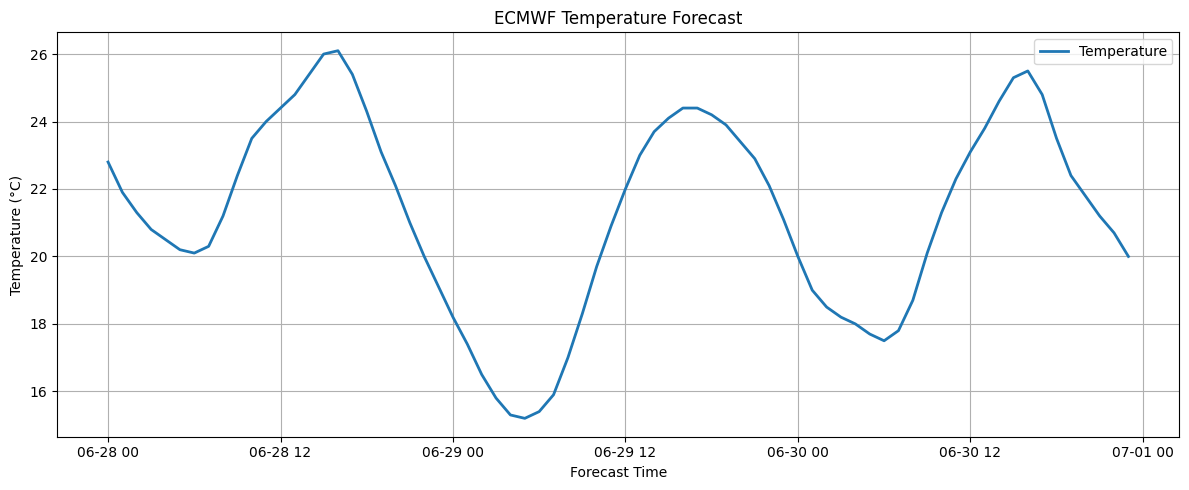

In [8]:
# -----------------------------
# Plot Temperature Forecast
# -----------------------------
plt.figure(figsize=(12,5))

plt.plot(
    df["forecast_time"],
    df["temperature"],
    linewidth=2,
    label="Temperature"
)

plt.xlabel("Forecast Time")
plt.ylabel("Temperature (°C)")
plt.title("ECMWF Temperature Forecast")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
